In [1]:
%%javascript
IPython.notebook.kernel.execute('nb_name = "' + IPython.notebook.notebook_name + '"')

<IPython.core.display.Javascript object>

In [1]:
%load_ext autoreload
%autoreload 2
import os
import time
from tqdm import tqdm
import wandb
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets, models
import torch.nn.functional as F

import sys
sys.path.append('../../../helper_functions/')
from visualization_functions import show_images

sys.path.append('../src/')
from h5_functions import list_to_dict, hdf5_dataset, viz_dataloader

from spatial_transformer_functions import Attention_affine_model_every_level
from train_functions import train_epochs


symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

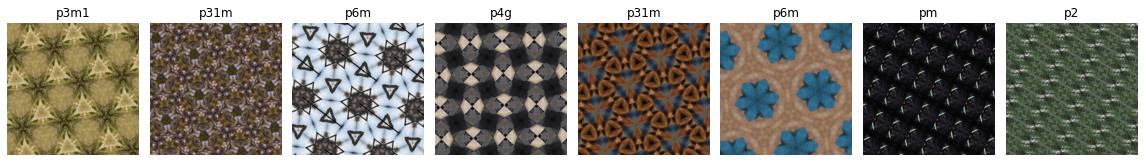

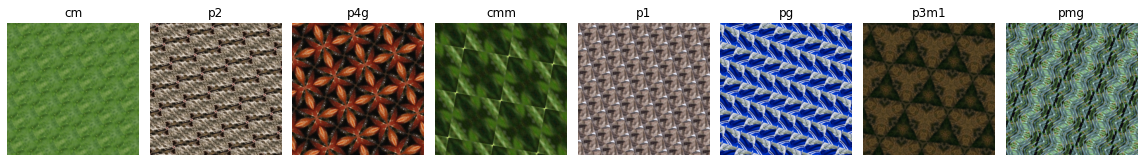

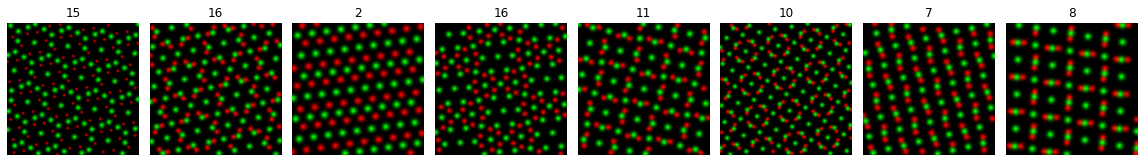

CPU times: user 25.1 s, sys: 915 ms, total: 26 s
Wall time: 5.27 s


In [2]:
%%time
# imagenet
train_ds = hdf5_dataset('/scratch/yichen/imagenet_v4_rot_10m_5percent_subset.h5', folder='train', transform=transforms.ToTensor())
train_dl = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=4)
viz_dataloader(train_dl, label_converter=label_converter)

valid_ds = hdf5_dataset('/scratch/yichen/imagenet_v4_rot_10m_5percent_subset.h5', folder='valid', transform=transforms.ToTensor())
valid_dl = DataLoader(valid_ds, batch_size=256, shuffle=True, num_workers=4)
viz_dataloader(valid_dl, label_converter=label_converter)

test_ds = hdf5_dataset('/scratch/yichen/imagenet_v4_rot_10m_5percent_subset.h5', folder='test', transform=transforms.ToTensor())
test_dl = DataLoader(test_ds, batch_size=256, shuffle=True, num_workers=4)
viz_dataloader(test_dl)

In [3]:
model = Attention_affine_model_every_level(image_channels=3)
print(model)
theta = model(torch.randn(5, 3, 256, 256))
print(theta.shape)

/scratch/yichen/anaconda3/envs/gyc/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/scratch/yichen/anaconda3/envs/gyc/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Attention_affine_model_every_level(
  (resnet50): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsam

/scratch/yichen/anaconda3/envs/gyc/lib/python3.8/site-packages/torch/nn/functional.py:4298: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(
/scratch/yichen/anaconda3/envs/gyc/lib/python3.8/site-packages/torch/nn/functional.py:4236: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(


torch.Size([5, 17])


In [4]:
config = {
    'dataset': 'imagenet_v4_rot_10m_5percent_subset.h5',
    'device': torch.device('cuda:3'),
    'loss_func': 'CrossEntropyLoss' , # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
    'dropout': 0.5
}

NAME = '12012023-resnet_spatial_fv_concatenate-every_level'

# train

In [5]:
# os.environ["WANDB_NOTEBOOK_NAME"] = nb_name
wandb.init(project='symmetry_paper', entity='yig319', name=NAME, id=NAME, save_code=True, config=config)
config = wandb.config

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yig319. Use `wandb login --relogin` to force relogin


In [6]:
device = config['device']
lr = 1e-3
start = 0
epochs = 50

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, test_dl, epochs=epochs, start=start, 
                       scheduler=scheduler, model_name=NAME, model_dir='/scratch/yichen/models_new/', tracking=True)

Epoch: 1/50


  0%|          | 0/391 [00:00<?, ?it/s]

/scratch/yichen/anaconda3/envs/gyc/lib/python3.8/site-packages/torch/nn/functional.py:4298: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(
/scratch/yichen/anaconda3/envs/gyc/lib/python3.8/site-packages/torch/nn/functional.py:4236: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(
100%|██████████| 391/391 [04:09<00:00,  1.57it/s]


Training: Loss: 3.0353, Accuracy: 5.9110%, Time: 4.1538mins


100%|██████████| 391/391 [01:27<00:00,  4.47it/s]


...

Training: Loss: 2.8324, Accuracy: 6.3110%, Time: 3.9607mins


100%|██████████| 391/391 [01:29<00:00,  4.37it/s]


Validation : Loss : 2.8327, Accuracy: 6.1920%, Time: 1.49mins


100%|██████████| 391/391 [01:35<00:00,  4.09it/s]


Validation : Loss : 2.8382, Accuracy: 5.9720%, Time: 1.59mins


# analyze

In [7]:
model = torch.load('/scratch/yichen/models/12012023-resnet_spatial_fv_concatenate-50.pt')

In [7]:
sys.path.append('../src/')
from confusion_matrix_functions import confusion_matrix, plot_cm

symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                    'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
NAME = '12012023-resnet_spatial_fv_concatenate-every_level'

In [8]:
device = torch.device('cuda:3')

cm = confusion_matrix(model, train_dl, symmetry_classes, device, n_batches='all')
np.save(NAME+'-train_cm.npy', cm)

NameError: name 'torch' is not defined

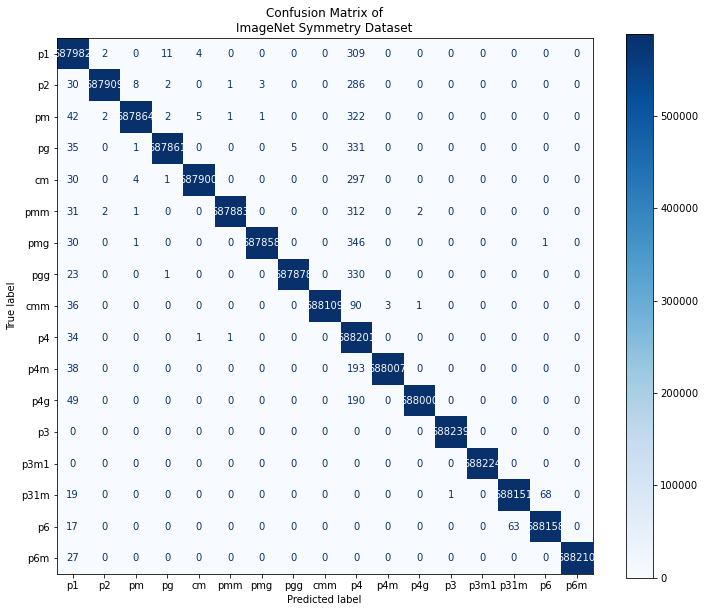

In [ ]:
# cm = np.load('11172021-benchmark_atom-fpn_spatial-transfer_learning-train.npy')

plot_cm(cm, symmetry_classes, save_file=None, title='\nImageNet Symmetry Dataset', style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [ ]:
cm = confusion_matrix(model, valid_dl, symmetry_classes, device, n_batches='all')
np.save(NAME+'-valid_cm.npy', cm)

100%|██████████| 8696/8696 [27:55<00:00,  5.19it/s]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,117670.0,117647.0,117647.0,117647.0,117646.0,117646.0,117648.0,117647.0,117647.0,117646.0,117647.0,117648.0,117647.0,117645.0,117645.0,117646.0,117647.0


Accuracy for these batches: 0.9991540067679459


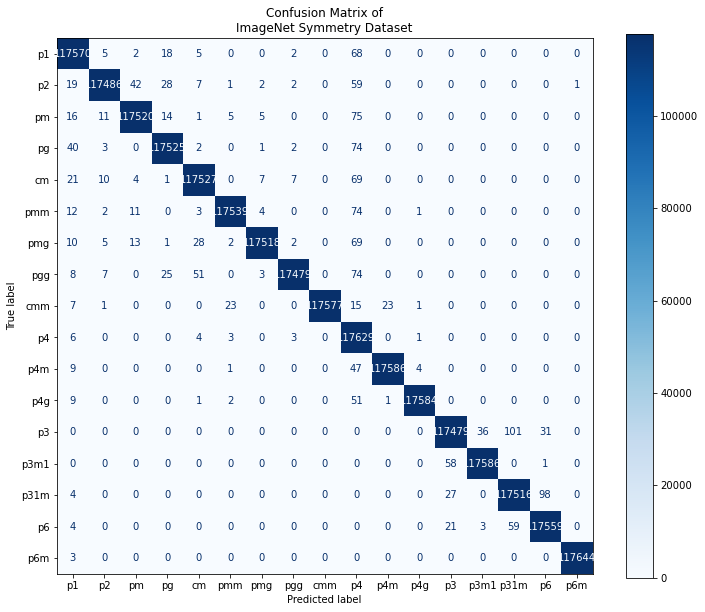

In [ ]:
# cm = np.load('11172021-benchmark_imagenet-fpn_spatial-transfer_learning-valid.npy')

plot_cm(cm, symmetry_classes, save_file=None, title='\nImageNet Symmetry Dataset', style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [ ]:
cm = confusion_matrix(model, test_dl, symmetry_classes, device, n_batches='all')
np.save(NAME+'-test_cm.npy', cm)

100%|██████████| 1985/1985 [29:26<00:00,  1.12it/s]


Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,270351.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0


Accuracy for these batches: 0.5805782531969523


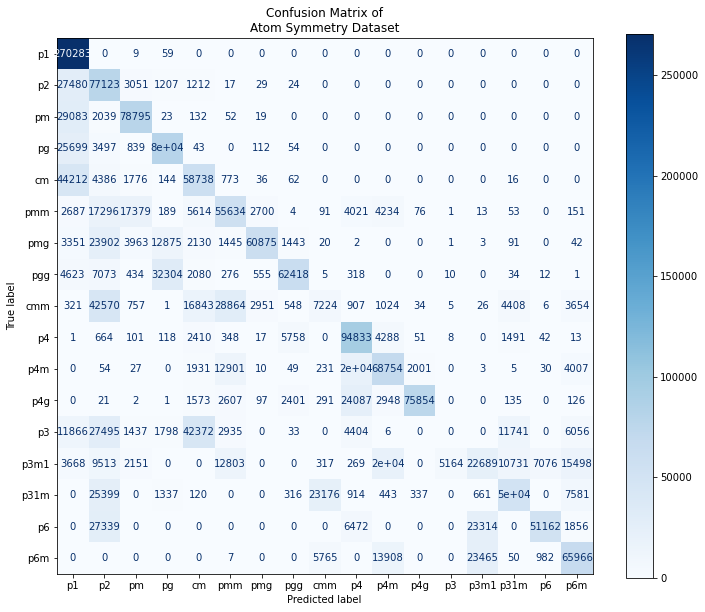

In [ ]:
# cm = np.load('05232022-benchmark-resnet50_from_scratch-dataset_v3-test.npy')

plot_cm(cm, symmetry_classes, save_file=None, title='\nAtom Symmetry Dataset', style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [ ]:
import sys
sys.path.append('../../../helper_functions/')
from python_email import send_email
send_email()

In [ ]:
from IPython.display import display_html
def restartkernel() :
    display_html("<script>Jupyter.notebook.kernel.restart()</script>",raw=True)
restartkernel()